In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from google.colab import files

uploaded = files.upload()

file_name = next(
    name for name in uploaded.keys()
    if name.endswith(".parquet")
)

df = pd.read_parquet(file_name)

print(df.shape)
df.head()

Saving yellow_tripdata_2024-01.parquet to yellow_tripdata_2024-01.parquet
(2964624, 19)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,N,186,79,2,17.7,1.0,0.5,0.00,0.0,1.0,22.70,2.5,0.0
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,N,140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,N,236,79,1,23.3,3.5,0.5,3.00,0.0,1.0,31.30,2.5,0.0
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,1.0,N,79,211,1,10.0,3.5,0.5,2.00,0.0,1.0,17.00,2.5,0.0
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,1.0,N,211,148,1,7.9,3.5,0.5,3.20,0.0,1.0,16.10,2.5,0.0


In [4]:
# Create pickup hour
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour

# Count trips by hour
trips_by_hour = (
    df.groupby("pickup_hour")
      .size()
      .reset_index(name="total_trips")
)

trips_by_hour

,pickup_hour,total_trips
0,0,79094
1,1,53627
2,2,37517
3,3,24811
4,4,16742
5,5,18764
6,6,41429
7,7,83719
8,8,117209
9,9,128970


In [5]:
print("df exists:", "df" in globals())

df exists: True


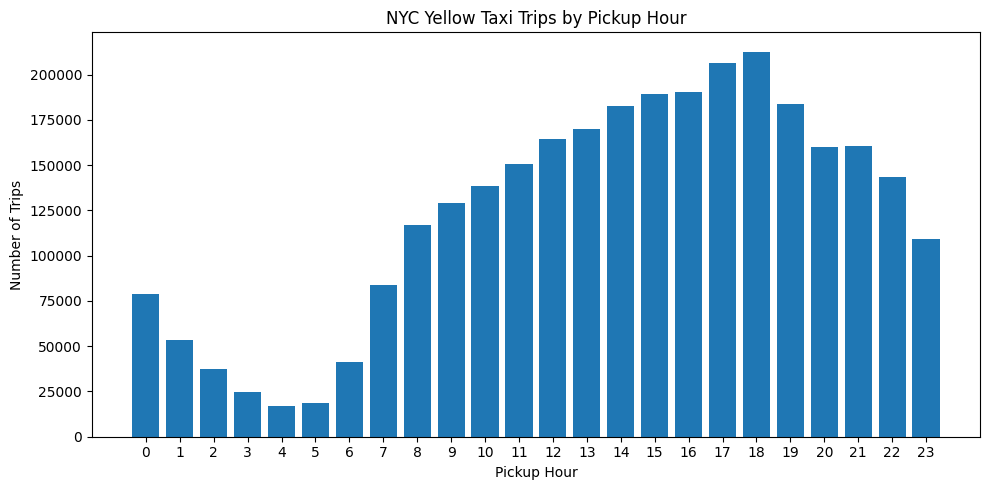

In [6]:
plt.figure(figsize=(10, 5))

plt.bar(
    trips_by_hour["pickup_hour"],
    trips_by_hour["total_trips"]
)

plt.title("NYC Yellow Taxi Trips by Pickup Hour")
plt.xlabel("Pickup Hour")
plt.ylabel("Number of Trips")
plt.xticks(range(24))
plt.tight_layout()

plt.show()

In [7]:
# Keep January trips with positive total_amount
positive_january = df[
    (df["tpep_pickup_datetime"] >= "2024-01-01") &
    (df["tpep_pickup_datetime"] < "2024-02-01") &
    (df["total_amount"] > 0)
].copy()

# Sum gross recorded trip amount by pickup hour
gross_by_hour = (
    positive_january
    .groupby(positive_january["tpep_pickup_datetime"].dt.hour)["total_amount"]
    .sum()
    .reset_index()
)

gross_by_hour.columns = ["pickup_hour", "gross_recorded_trip_amount"]

gross_by_hour

,pickup_hour,gross_recorded_trip_amount
0,0,2231420.55
1,1,1381821.33
2,2,918354.26
3,3,656174.46
4,4,529886.93
5,5,690685.36
6,6,1235228.02
7,7,2206441.82
8,8,2976175.93
9,9,3315887.20


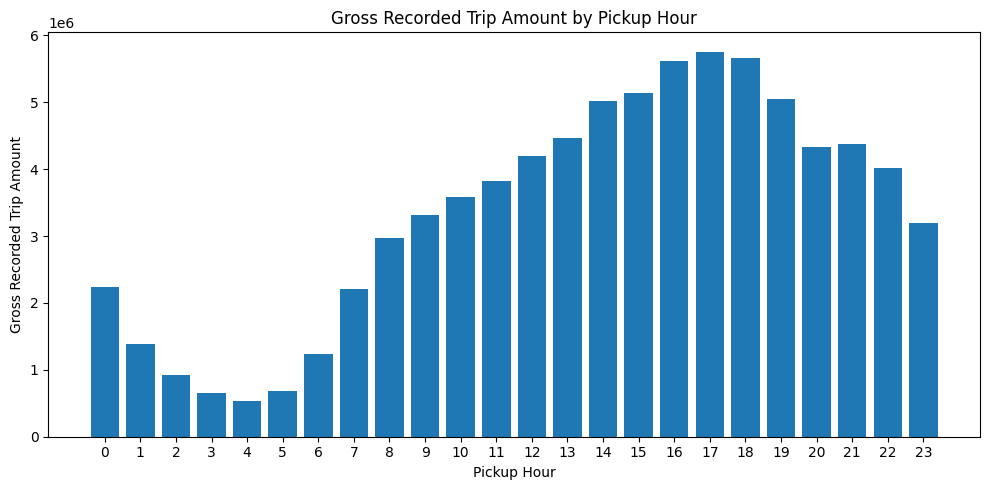

In [8]:
plt.figure(figsize=(10, 5))

plt.bar(
    gross_by_hour["pickup_hour"],
    gross_by_hour["gross_recorded_trip_amount"]
)

plt.title("Gross Recorded Trip Amount by Pickup Hour")
plt.xlabel("Pickup Hour")
plt.ylabel("Gross Recorded Trip Amount")
plt.xticks(range(24))
plt.tight_layout()

plt.show()

In [9]:
# Keep rows suitable for distance analysis
distance_df = df[
    (df["tpep_pickup_datetime"] >= "2024-01-01") &
    (df["tpep_pickup_datetime"] < "2024-02-01") &
    (df["total_amount"] > 0) &
    (df["trip_distance"] > 0) &
    (df["trip_distance"] <= 500)
].copy()

# Create distance segments
distance_df["distance_segment"] = pd.cut(
    distance_df["trip_distance"],
    bins=[0, 2, 5, 10, float("inf")],
    labels=[
        "Short (0-2)",
        "Medium (2-5)",
        "Long (5-10)",
        "Very Long (10+)"
    ]
)

# Aggregate by segment
distance_summary = (
    distance_df
    .groupby("distance_segment", observed=True)
    .agg(
        total_amount=("total_amount", "sum"),
        total_distance=("trip_distance", "sum")
    )
    .reset_index()
)

distance_summary["gross_amount_per_mile"] = (
    distance_summary["total_amount"]
    / distance_summary["total_distance"]
)

distance_summary

,distance_segment,total_amount,total_distance,gross_amount_per_mile
0,Short (0-2),27972274.15,1899596.87,14.725374
1,Medium (2-5),20213474.10,2252085.72,8.975446
2,Long (5-10),11006911.33,1680180.60,6.551029
3,Very Long (10+),19294880.30,3629421.47,5.316241


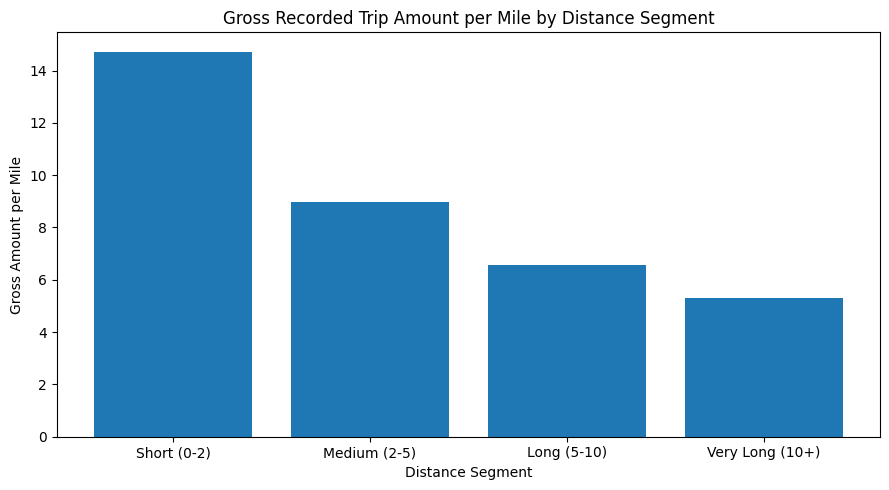

In [10]:
plt.figure(figsize=(9, 5))

plt.bar(
    distance_summary["distance_segment"],
    distance_summary["gross_amount_per_mile"]
)

plt.title("Gross Recorded Trip Amount per Mile by Distance Segment")
plt.xlabel("Distance Segment")
plt.ylabel("Gross Amount per Mile")
plt.tight_layout()

plt.show()